In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('hotel_restaurant_orders.csv')

In [ ]:
#filling missing special requests
df['SpecialRequest']=df['SpecialRequest'].fillna("None")

In [ ]:
#converting order date to a date format
df['OrderDate']=pd.to_datetime(df["OrderDate"])

In [ ]:
#replacing - values
df["ServerName"]=df['ServerName'].str.replace("-",'N/A')
df['TableNumber']=df['TableNumber'].str.replace("-",'N/A')

In [ ]:
#adding revenue column
df['RevenueCategory']=df['TotalPrice'].apply(lambda x: "High" if x>=30 else "Medium" if x>=15 else "Low")

In [ ]:
#total revenue generated
total_rev=df['TotalPrice'].sum()
print(f"Total revenue generated : {total_rev} USD")

In [ ]:
#most rev per restaurant type 
most_per_type=df.groupby('RestaurantType')["TotalPrice"].sum()
print(f"Restaurant type with most revenue: {most_per_type.idxmax()}")

In [ ]:
#most ordered item
most_ordered=df["ItemName"].value_counts().idxmax()
print(f"Most ordered item name: {most_ordered}")

In [ ]:
#Highest average menu category
avg_total=round(df.groupby('MenuCategory')['TotalPrice'].mean())
print(avg_total)

In [ ]:
#Most popular payment method
most_pmethod=df.groupby('PaymentMethod')['PaymentMethod'].count()
print(most_pmethod.idxmax())

In [ ]:
#Most orders per day
day_most_orders=df.groupby("DayOfWeek")['OrderID'].count()
print(day_most_orders.idxmax())

In [ ]:
#time with most orders
most_rev_time=df.groupby("TimeOfDay")['TotalPrice'].sum()
print(most_rev_time.idxmax())

In [ ]:
#percentage that has special requests
df['SpecialRequest']=df['SpecialRequest'].apply(lambda x: False if x=='None' else True)
percentage=round((df['SpecialRequest'].sum())*100/len(df['SpecialRequest']))
print(f"Percentage of orders with special request: {percentage}%")

In [ ]:
#Restaurant type with highest average order value
order_per_type=df.groupby('RestaurantType')['TotalPrice'].mean()
print(order_per_type.idxmax())

In [ ]:
#Top 5 customers by spending
top_five=df.groupby('CustomerName')['TotalPrice'].sum()
print(top_five.nlargest(5))

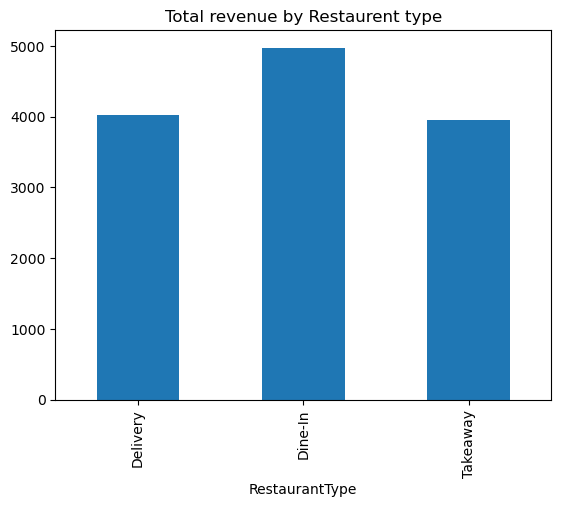

In [ ]:
#data visualization
#Bar chart for revenue by restaurant type
total_by_type=df.groupby('RestaurantType')['TotalPrice'].sum()
bar_chart=total_by_type.plot(kind="bar",title="Total revenue by Restaurent type")
plt.show()

<Axes: title={'center': ' Bar chart of order count by days of week'}, xlabel='DayOfWeek'>

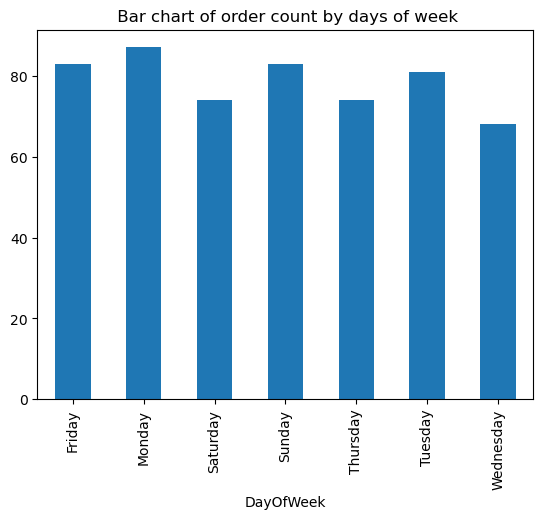

In [ ]:
#Bar chart of the order count by week days
busiest_day=df.groupby("DayOfWeek")['OrderID'].count()
busiest_day.plot(kind="bar",title=" Bar chart of order count by days of week")
plt.show()

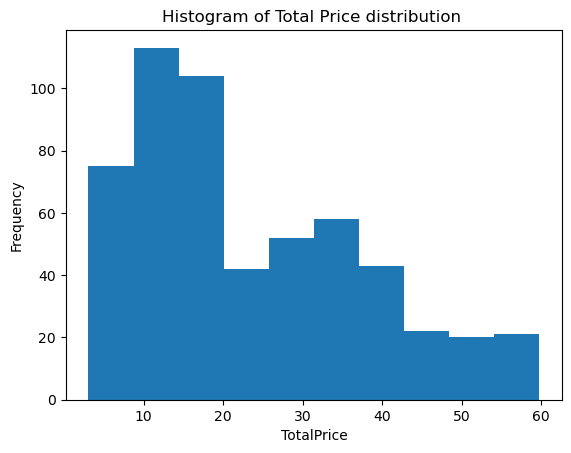

In [68]:
#Histogram of total price distribution
total_price=df['TotalPrice']
total_price.plot(kind='hist',title="Histogram of Total Price distribution ")
plt.xlabel('TotalPrice')
plt.show()